# Transfer Learning: Reusing a Pretrained Vision Transformer

This is the fifth notebook in the series, and the first that does not build a
representation from scratch. Notebooks 1 to 4 all started from random weights
and learned everything from the training set. Here we start from a ViT that
someone else trained on ImageNet, and ask a different question: **how much of
what it learned is useful for a task it has never seen?**

That is the question you face in practice. Training a Vision Transformer from
scratch needs data you usually do not have — notebook 4 made that concrete, at
11.6× the CNN's parameters for the same accuracy on 33,600 images. Fine-tuning
a pretrained backbone is what you do instead.

## What changes from notebook 4

| | Notebook 4 | This notebook |
|---|---|---|
| Starting weights | random | pretrained on ImageNet-1k |
| Dataset | MNIST, 33,600 images | Oxford-IIIT Pet, 37 breeds, **20 images per class** |
| Input | $28 \times 28$ grayscale | $224 \times 224$ RGB |
| Model | 105,098 parameters, written by hand | 86.6M parameters, `torchvision.models.vit_b_16` |
| What we train | everything | a new head, then some attention layers |

The training set is small on purpose. Transfer learning earns its keep exactly
where data is scarce, so 20 images per class — 740 in total — is the regime
worth demonstrating. From scratch, that is hopeless. We will measure how
hopeless, as the control.

## The experiment

The series' method is to change one thing at a time, and it applies here too.
The central comparison holds the architecture, the data, the head, and the
training budget fixed, and changes **only whether the backbone's weights are
the pretrained ones or random**:

| Backbone weights | What we train | Expected |
|---|---|---|
| Pretrained on ImageNet | a linear head | high |
| Random | the same linear head | low |

Whatever separates those two numbers is what the pretraining bought.

## Prerequisites

Notebook 4, or familiarity with the ViT architecture. Everything specific to
transfer learning is developed here.

> **This notebook downloads things.** A ~330 MB model checkpoint and a ~800 MB
> dataset, both cached after the first run — about ten minutes in total, most
> of it the dataset. That is a break from notebooks 1–4, which ship with
> everything they need, and it is unavoidable: the whole point is to reuse
> weights we did not train.

---
## 1. Setup

Nothing here is new except `torchvision`, which supplies both the pretrained
model and the dataset.

In [1]:
import json
import time
from collections import OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torchvision.models import ViT_B_16_Weights, vit_b_16

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"torch {torch.__version__}  |  device: {device}")

/opt/anaconda3/envs/torch_mac_metal_gpu/lib/python3.11/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/opt/anaconda3/envs/torch_mac_metal_gpu/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <EB3FF92A-5EB1-3EE8-AF8B-5923C1265422> /opt/anaconda3/envs/torch_mac_metal_gpu/lib/python3.11/site-packages/torchvision/image.so
  Reason: tried: '/opt/anaconda3/envs/torch_mac_metal_gpu/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/torch_mac_metal_gpu/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/torch_mac_metal_gpu/lib/python3.11/lib-dynload/../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/torch_mac_metal_gpu/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warnin

torch 2.5.1.post8  |  device: mps


### Configuration

The two knobs that control runtime. `TRAIN_PER_CLASS` is the point of the
notebook, so leave it small. `TEST_PER_CLASS` trades evaluation precision for
time — set it to `None` to use the full 3,669-image test split.

`RUN_FINETUNE` controls Section 10, which is the only part that back-propagates
through the whole backbone. On a GPU it takes a couple of minutes; on a CPU it
takes considerably longer, which is why it is a flag.

In [2]:
TRAIN_PER_CLASS = 20      # images per breed used for training  (37 x 20 = 740)
VAL_PER_CLASS = 5         # held out from trainval for model selection
TEST_PER_CLASS = 25       # None uses the entire test split (3,669 images)

PROBE_EPOCHS = 300        # head-only training on cached features: seconds
FINETUNE_EPOCHS = 4       # backprop through the backbone: minutes on a GPU
RUN_FINETUNE = device in ("cuda", "mps")

DATA_ROOT = "data"        # torchvision appends "oxford-iiit-pet" itself

print(f"training images: {TRAIN_PER_CLASS * 37}")
print(f"fine-tuning section will run: {RUN_FINETUNE}")

training images: 740
fine-tuning section will run: True


---
## 2. The data

*This is step 3 of the notes: split, resize, augment.*

**Oxford-IIIT Pet** is 37 cat and dog breeds, about 200 images each. It is a
*fine-grained* task — the classes are Abyssinian versus Bengal versus Birman,
not cat versus car — which matters for what follows. Fine-grained distinctions
are exactly where a generic pretrained representation is tested: ImageNet
contains many dog breeds, so some of this is familiar to the backbone, but the
task boundary is different.

### Three splits, and why the transforms differ

The training images get augmentation — random crops and horizontal flips — to
manufacture variety we do not have. The validation and test images get none, so
that what we measure is performance rather than an average over random
distortions. Getting this backwards is a common and silent mistake.

### Normalization is not optional

A pretrained model expects inputs standardized the same way they were during
pretraining. The weights encode an assumption about the input distribution, and
violating it degrades accuracy without raising any error. `torchvision` ships
the exact preprocessing alongside the weights, so we read the constants from
there rather than typing them from memory.

In [3]:
weights = ViT_B_16_Weights.IMAGENET1K_V1
preprocess = weights.transforms()

MEAN = preprocess.mean
STD = preprocess.std
SIZE = preprocess.crop_size[0]

print("the preprocessing these weights were trained with:")
print(preprocess)
print(f"\nmean {MEAN}\nstd  {STD}\nresolution {SIZE} x {SIZE}")

the preprocessing these weights were trained with:
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

mean [0.485, 0.456, 0.406]
std  [0.229, 0.224, 0.225]
resolution 224 x 224


In [4]:
# Training: augmented. Evaluation: deterministic, matching the pretraining.
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

### Where the data comes from

`torchvision` fetches Oxford-IIIT Pet from the University of Oxford, which is
the authoritative source and also, when this notebook was written, served the
792 MB image archive at roughly **100 kB/s** — over two hours.

The identical archive is mirrored on fast.ai's S3 bucket at about **2 MB/s**,
which turns that into six minutes. The cell below tries the mirror first and
leaves `download=True` on the dataset constructor as the fallback: if the
mirror is unreachable, `torchvision` notices the data is missing and fetches it
the slow way, so the notebook still works either way.

This is worth a moment of a student's attention. Where a dataset is hosted has
nothing to do with the science and everything to do with whether an experiment
takes ten minutes or an afternoon, and checking before you wait is a habit
worth forming.

In [5]:
import sys
import tarfile
import urllib.request
from pathlib import Path

PET_MIRROR = "https://s3.amazonaws.com/fast-ai-imageclas/oxford-iiit-pet.tgz"
PET_ANNOTATIONS = "https://thor.robots.ox.ac.uk/pets/annotations.tar.gz"


def _fetch(url, destination):
    """Download with a one-line progress report."""
    def report(block, block_size, total):
        done = block * block_size
        if total > 0:
            pct = 100 * done / total
            print(f"\r  {done / 1e6:7.1f} / {total / 1e6:.1f} MB  ({pct:5.1f}%)", end="")
    urllib.request.urlretrieve(url, destination, reporthook=report)
    print()


def _extract(archive, into):
    # Python 3.12 deprecates the permissive default; "data" is the safe filter.
    kwargs = {"filter": "data"} if sys.version_info >= (3, 12) else {}
    with tarfile.open(archive) as tar:
        tar.extractall(into, **kwargs)


def ensure_pet_dataset(root=DATA_ROOT):
    """Put the dataset where torchvision expects it, using the fast mirror.

    Returns True if the data is complete, False to let torchvision handle it.
    """
    base = Path(root) / "oxford-iiit-pet"
    images, annotations = base / "images", base / "annotations"
    complete = lambda: (images.is_dir()
                        and (annotations / "trainval.txt").exists()
                        and (annotations / "test.txt").exists())

    if complete():
        print(f"dataset already present at {base}")
        return True

    Path(root).mkdir(parents=True, exist_ok=True)
    try:
        if not images.is_dir():
            print("images: fetching from the fast.ai mirror (~800 MB)")
            archive = Path(root) / "oxford-iiit-pet.tgz"
            _fetch(PET_MIRROR, archive)
            _extract(archive, root)
            archive.unlink()

        if not (annotations / "trainval.txt").exists():
            print("annotations: fetching from Oxford (~19 MB)")
            archive = Path(root) / "annotations.tar.gz"
            _fetch(PET_ANNOTATIONS, archive)
            _extract(archive, base)
            archive.unlink()
    except Exception as error:
        print(f"\nmirror route failed ({type(error).__name__}: {error})")
        print("falling back to torchvision's own download")
        return False

    print("ready" if complete() else "still incomplete; torchvision will fill the gaps")
    return complete()


ensure_pet_dataset()

dataset already present at data/oxford-iiit-pet


True

In [6]:
# download=True is the fallback: if the mirror above worked, torchvision sees
# the files already in place and does nothing.
trainval_raw = OxfordIIITPet(DATA_ROOT, split="trainval", download=True)
test_raw = OxfordIIITPet(DATA_ROOT, split="test", download=True)

CLASSES = trainval_raw.classes
N_CLASSES = len(CLASSES)

print(f"{N_CLASSES} breeds")
print(f"trainval: {len(trainval_raw)} images   test: {len(test_raw)} images")
print(f"\nfirst five: {CLASSES[:5]}")

37 breeds
trainval: 3680 images   test: 3669 images

first five: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle']


In [7]:
def dataset_labels(dataset):
    """Integer labels of a torchvision dataset, without decoding any images."""
    for attr in ("_labels", "targets", "labels"):
        if hasattr(dataset, attr):
            return np.asarray(getattr(dataset, attr))
    raise AttributeError("could not find the label list on this dataset")


def take_per_class(labels, n_per_class, rng, exclude=None):
    """Indices of n_per_class examples of every class, chosen without replacement."""
    exclude = set() if exclude is None else set(exclude)
    chosen = []
    for c in range(N_CLASSES):
        pool = np.array([i for i in np.flatnonzero(labels == c) if i not in exclude])
        rng.shuffle(pool)
        keep = pool if n_per_class is None else pool[:n_per_class]
        chosen.extend(int(i) for i in keep)
    return sorted(chosen)


rng = np.random.default_rng(SEED)
trainval_labels = dataset_labels(trainval_raw)
test_labels = dataset_labels(test_raw)

val_idx = take_per_class(trainval_labels, VAL_PER_CLASS, rng)
train_idx = take_per_class(trainval_labels, TRAIN_PER_CLASS, rng, exclude=val_idx)
test_idx = take_per_class(test_labels, TEST_PER_CLASS, rng)

assert not (set(train_idx) & set(val_idx)), "train and val overlap"

print(f"train {len(train_idx)}   val {len(val_idx)}   test {len(test_idx)}")
print(f"training images per class: {len(train_idx) // N_CLASSES}")

train 740   val 185   test 925
training images per class: 20


In [8]:
def subset(split, indices, transform):
    base = OxfordIIITPet(DATA_ROOT, split=split, transform=transform)
    return Subset(base, indices)


train_aug = subset("trainval", train_idx, train_transform)   # augmented
train_plain = subset("trainval", train_idx, eval_transform)  # for feature caching
val_set = subset("trainval", val_idx, eval_transform)
test_set = subset("test", test_idx, eval_transform)

BATCH = 32
loaders = {
    "train_aug": DataLoader(train_aug, batch_size=BATCH, shuffle=True),
    "train": DataLoader(train_plain, batch_size=BATCH),
    "val": DataLoader(val_set, batch_size=BATCH),
    "test": DataLoader(test_set, batch_size=BATCH),
}
for name, loader in loaders.items():
    print(f"{name:10s} {len(loader.dataset):5d} images  {len(loader):3d} batches")

train_aug    740 images   24 batches
train        740 images   24 batches
val          185 images    6 batches
test         925 images   29 batches


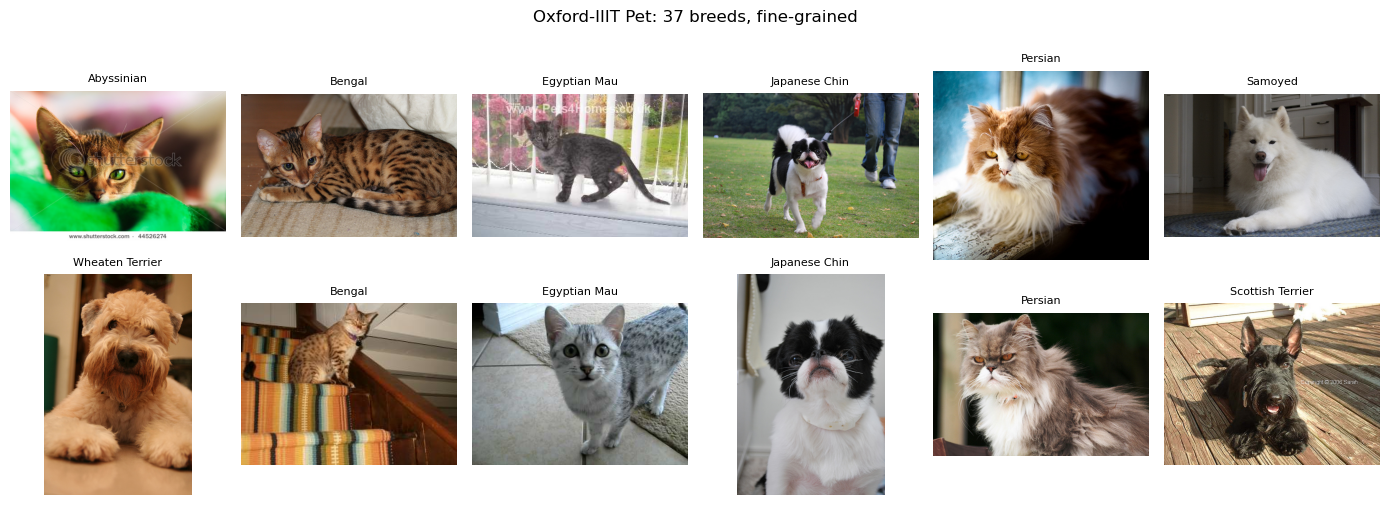

In [9]:
# A look at what we are working with, un-normalized for display.
show = OxfordIIITPet(DATA_ROOT, split="trainval")
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, i in zip(axes.ravel(), train_idx[::max(1, len(train_idx) // 12)][:12]):
    image, label = show[i]
    ax.imshow(image)
    ax.set_title(CLASSES[label], fontsize=8)
    ax.axis("off")
fig.suptitle("Oxford-IIIT Pet: 37 breeds, fine-grained", y=1.0)
plt.tight_layout()
plt.show()

---
## 3. The pretrained backbone

*This is step 1 of the notes.*

`vit_b_16` is the architecture of notebook 4, scaled up and trained properly:
12 transformer blocks instead of 2, width 768 instead of 64, 12 heads instead
of 4, and $16 \times 16$ patches over a $224 \times 224$ image instead of
$7 \times 7$ over $28 \times 28$.

Everything you implemented by hand in notebook 4 is in here — the patch
embedding, the `[CLS]` token, the positional embeddings, scaled dot-product
attention, the pre-norm blocks. The difference is the 86.6 million parameters
and the ImageNet training run behind them, which is what we are borrowing.

In [10]:
t0 = time.time()
backbone = vit_b_16(weights=weights)   # downloads ~330 MB the first time
print(f"loaded in {time.time() - t0:.1f}s")

n_params = sum(p.numel() for p in backbone.parameters())
print(f"parameters: {n_params:,}")
print(f"reported ImageNet-1k top-1: {weights.meta['_metrics']['ImageNet-1K']['acc@1']}%")
print(f"\nnotebook 4's ViT had 105,098 parameters — this is {n_params / 105_098:.0f}x larger")

loaded in 0.6s
parameters: 86,567,656
reported ImageNet-1k top-1: 81.072%

notebook 4's ViT had 105,098 parameters — this is 824x larger


In [11]:
# The same pieces as notebook 4, at a different scale.
print(f"patch size:          {backbone.patch_size}")
print(f"image size:          {backbone.image_size}")
print(f"encoder blocks:      {len(backbone.encoder.layers)}")
print(f"class token:         {tuple(backbone.class_token.shape)}")
print(f"positional embed:    {tuple(backbone.encoder.pos_embedding.shape)}")
print(f"head:                {backbone.heads}")

block = backbone.encoder.layers[0]
print(f"\none block: {[name for name, _ in block.named_children()]}")
print(f"  ln_1 -> self_attention -> ln_2 -> mlp, pre-norm, exactly as in notebook 4 §7.4")

patch size:          16
image size:          224
encoder blocks:      12
class token:         (1, 1, 768)
positional embed:    (1, 197, 768)
head:                Sequential(
  (head): Linear(in_features=768, out_features=1000, bias=True)
)

one block: ['ln_1', 'self_attention', 'dropout', 'ln_2', 'mlp']
  ln_1 -> self_attention -> ln_2 -> mlp, pre-norm, exactly as in notebook 4 §7.4


The positional embedding is $1 \times 197 \times 768$. That 197 is
$14 \times 14 + 1$: a $224 \times 224$ image cut into $16 \times 16$ patches
gives a $14 \times 14$ grid, plus the `[CLS]` token prepended. Section 5 returns
to what that number ties us to.

---
## 4. Backbone and head

*This is step 4 of the notes: replace the classification head.*

A classifier splits cleanly in two:

- the **backbone**, which maps an image to a feature vector — here, the 768-dimensional `[CLS]` representation after the final LayerNorm;
- the **head**, a single linear layer mapping that vector to class scores.

The backbone holds everything general the model learned about images. The head
holds the one thing that is specific to ImageNet: which 1,000 categories to
name. Our task has 37 categories that are not those 1,000, so the head is the
part that cannot transfer and must be thrown away.

In `torchvision`'s ViT the head is `model.heads.head`, a
`Linear(768 → 1000)`. Replacing it with `Linear(768 → 37)` is the whole
operation.

In [12]:
FEATURE_DIM = backbone.heads.head.in_features
print(f"backbone output: {FEATURE_DIM}-dimensional")
print(f"old head: {backbone.heads.head}   ({backbone.heads.head.out_features} ImageNet classes)")

# Setting heads to Identity turns the model into a pure feature extractor.
backbone.heads = nn.Identity()

with torch.no_grad():
    probe_input = torch.zeros(2, 3, SIZE, SIZE)
    features = backbone(probe_input)
print(f"\nwith heads replaced by Identity: {tuple(probe_input.shape)} -> {tuple(features.shape)}")
print("that 768-vector is the [CLS] token's final representation — notebook 4 §4.3")

backbone output: 768-dimensional
old head: Linear(in_features=768, out_features=1000, bias=True)   (1000 ImageNet classes)



with heads replaced by Identity: (2, 3, 224, 224) -> (2, 768)
that 768-vector is the [CLS] token's final representation — notebook 4 §4.3


---
## 5. Positional embeddings are tied to a resolution

*This is one of the refinements in the notes, and notebook 4 §4.2 predicted it.*

Notebook 4 made the point in the abstract: learned positional embeddings are
indexed by patch, so they are tied to the grid they were trained on. Here is
the concrete consequence.

This backbone holds 196 positional vectors for a $14 \times 14$ grid. Feed it
$384 \times 384$ images and the grid becomes $24 \times 24 = 576$ patches —
576 positions for which only 196 embeddings exist. The model cannot run.

There are two ways out:

1. **Resize your inputs to 224.** Free, and what most fine-tuning recipes do. It is why Section 2 resizes to exactly `preprocess.crop_size`.
2. **Interpolate the embeddings onto the new grid.** Reshape the 196 vectors into a $14 \times 14 \times 768$ spatial map, resample it bicubically to $24 \times 24$, and flatten back. The `[CLS]` embedding is carried across untouched, since it has no position.

`torchvision` provides the second as a function, which is worth running once so
the operation stops being hypothetical.

In [13]:
from torchvision.models.vision_transformer import interpolate_embeddings

pretrained_state = torch.hub.load_state_dict_from_url(weights.url, progress=False)
before = pretrained_state["encoder.pos_embedding"]

resized_state = interpolate_embeddings(
    image_size=384, patch_size=16, model_state=pretrained_state,
    interpolation_mode="bicubic",
)
after = resized_state["encoder.pos_embedding"]

print(f"224 x 224:  {tuple(before.shape)}   -> {int((before.shape[1] - 1) ** 0.5)} x {int((before.shape[1] - 1) ** 0.5)} grid + CLS")
print(f"384 x 384:  {tuple(after.shape)}   -> {int((after.shape[1] - 1) ** 0.5)} x {int((after.shape[1] - 1) ** 0.5)} grid + CLS")
print(f"\nCLS embedding carried across unchanged: {torch.allclose(before[:, 0], after[:, 0])}")

224 x 224:  (1, 197, 768)   -> 14 x 14 grid + CLS
384 x 384:  (1, 577, 768)   -> 24 x 24 grid + CLS

CLS embedding carried across unchanged: True


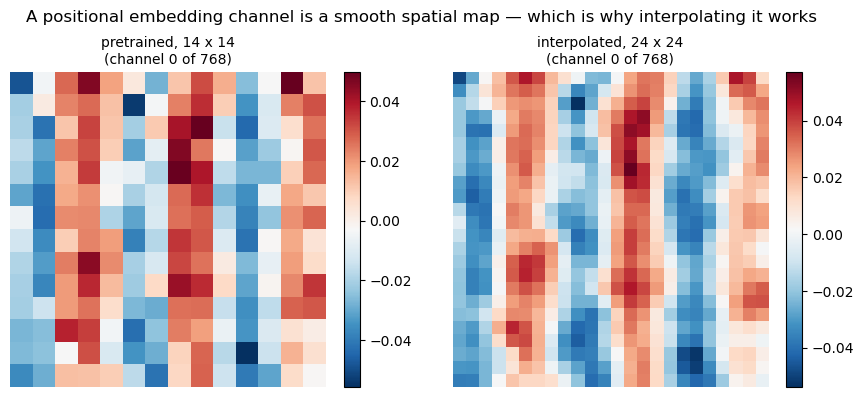

In [14]:
# What the embeddings look like as a spatial map, before and after.
def grid_of(pos_embedding, channel=0):
    patches = pos_embedding[0, 1:, channel]          # drop CLS
    side = int(patches.numel() ** 0.5)
    return patches.reshape(side, side).detach().numpy()


fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, emb, title in [(axes[0], before, "pretrained, 14 x 14"),
                       (axes[1], after, "interpolated, 24 x 24")]:
    im = ax.imshow(grid_of(emb), cmap="RdBu_r")
    ax.set_title(f"{title}\n(channel 0 of 768)", fontsize=10)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("A positional embedding channel is a smooth spatial map — which is why interpolating it works")
plt.tight_layout()
plt.show()

The smoothness is the justification. If the positional embeddings were
unstructured noise, resampling them would be meaningless. They are not: a
channel of the learned embedding varies smoothly across the patch grid, because
neighbouring patches occupy neighbouring positions and the model learned to
encode that. Bicubic interpolation of a smooth field is a reasonable operation,
and empirically it preserves most of the accuracy.

We keep our inputs at 224 for the rest of the notebook, which sidesteps the
issue entirely.

---
## 6. Freezing

*This is step 2 of the notes.*

Fine-tuning every one of 86.6 million parameters on 740 images would overfit
immediately, and would also discard the representation we came for. Freezing
means setting `requires_grad = False`, after which autograd builds no gradient
for those tensors and the optimizer never updates them.

Three strategies, in increasing order of cost and capacity:

| Strategy | Trainable | When |
|---|---|---|
| **Linear probe** — freeze everything but the head | ~28K | very little data; fastest; a strong baseline |
| **Partial fine-tune** — also unfreeze the last few blocks or the attention layers | millions | some data; the usual choice |
| **Full fine-tune** — unfreeze everything | 86.6M | lots of data, or a large domain shift |

The notes suggest leaving the attention layers trainable, which is the middle
row. We will do the linear probe first, because it is fast and because it
isolates the question we actually want to answer.

In [15]:
def set_trainable(model, predicate):
    """Unfreeze exactly those parameters whose name satisfies predicate."""
    for name, param in model.named_parameters():
        param.requires_grad = predicate(name)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total


trainable, total = set_trainable(backbone, lambda name: False)
print(f"backbone frozen: {trainable:,} of {total:,} trainable")

# What a partial fine-tune would open up, for comparison.
tr_attn, _ = set_trainable(backbone, lambda n: "self_attention" in n)
print(f"attention layers only:      {tr_attn:,}  ({100 * tr_attn / total:.1f}%)")
tr_last, _ = set_trainable(backbone, lambda n: any(f"layers.encoder_layer_{i}." in n for i in (10, 11)))
print(f"last two blocks:            {tr_last:,}  ({100 * tr_last / total:.1f}%)")

set_trainable(backbone, lambda name: False)   # back to fully frozen
print(f"\nrefrozen for Section 7")

backbone frozen: 0 of 85,798,656 trainable
attention layers only:      28,348,416  (33.0%)
last two blocks:            14,175,744  (16.5%)

refrozen for Section 7


---
## 7. Caching the features

A frozen backbone computes the same 768-vector for a given image every epoch.
Recomputing it 40 times is 40 times the work for no benefit, so we push every
image through once and keep the features.

This is worth knowing as a technique, not just as a speed-up here: a linear
probe over cached features is the standard way to evaluate what a
representation contains, and it turns a GPU-scale problem into one that trains
in seconds on a laptop.

The one thing it gives up is augmentation — a cached feature corresponds to one
fixed view of the image. That is why `train_plain` uses the deterministic
transform. Section 10, which does augment, cannot use the cache.

In [16]:
@torch.no_grad()
def extract_features(model, loader, desc=""):
    """Run the frozen backbone over a loader once and keep the outputs."""
    model.eval().to(device)
    feats, labels = [], []
    t0 = time.time()
    for images, targets in loader:
        feats.append(model(images.to(device)).cpu())
        labels.append(targets)
    X = torch.cat(feats)
    y = torch.cat(labels)
    print(f"{desc:24s} {tuple(X.shape)}  in {time.time() - t0:.1f}s")
    return X, y


print("extracting features with the PRETRAINED backbone")
Xtr, ytr = extract_features(backbone, loaders["train"], "train")
Xva, yva = extract_features(backbone, loaders["val"], "val")
Xte, yte = extract_features(backbone, loaders["test"], "test")

extracting features with the PRETRAINED backbone


train                    (740, 768)  in 13.7s


val                      (185, 768)  in 3.0s


test                     (925, 768)  in 14.1s


---
## 8. Strategy A: the linear probe

*This is steps 5 and 6 of the notes: configure the training, then train.*

One `Linear(768 → 37)` on top of frozen features. $768 \times 37 + 37 = 28{,}453$
parameters — a quarter of notebook 4's whole model, and the only thing being
learned.

The training settings follow the notes. AdamW, a low learning rate because the
representation underneath is already close to what we need, cosine decay, and
we keep the parameters from the best validation epoch rather than the last one.

In [17]:
def train_head(X_train, y_train, X_val, y_val, epochs=PROBE_EPOCHS, lr=1e-3, seed=SEED):
    """Train a linear classifier on cached features; return it and its history."""
    torch.manual_seed(seed)
    head = nn.Linear(X_train.shape[1], N_CLASSES).to(device)
    optimizer = torch.optim.AdamW(head.parameters(), lr=lr, weight_decay=1e-4)
    schedule = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    Xt, yt = X_train.to(device), y_train.to(device)
    Xv, yv = X_val.to(device), y_val.to(device)

    history = {"train_acc": [], "val_acc": [], "train_loss": []}
    best_acc, best_state = 0.0, None

    for epoch in range(epochs):
        head.train()
        optimizer.zero_grad()
        logits = head(Xt)
        loss = criterion(logits, yt)
        loss.backward()
        optimizer.step()
        schedule.step()

        head.eval()
        with torch.no_grad():
            train_acc = (logits.argmax(1) == yt).float().mean().item()
            val_acc = (head(Xv).argmax(1) == yv).float().mean().item()

        history["train_loss"].append(loss.item())
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_acc:                      # keep the best, not the last
            best_acc = val_acc
            best_state = {k: v.clone() for k, v in head.state_dict().items()}

    head.load_state_dict(best_state)
    return head, history, best_acc

In [18]:
t0 = time.time()
probe_head, probe_hist, probe_val = train_head(Xtr, ytr, Xva, yva)
probe_time = time.time() - t0

with torch.no_grad():
    probe_test = (probe_head(Xte.to(device)).argmax(1).cpu() == yte).float().mean().item()

print(f"trained {PROBE_EPOCHS} epochs in {probe_time:.1f}s")
print(f"best validation accuracy: {probe_val:.4f}")
print(f"test accuracy:            {probe_test:.4f}")
print(f"\n{sum(p.numel() for p in probe_head.parameters()):,} trained parameters, "
      f"on {len(train_idx)} images")

trained 300 epochs in 1.1s
best validation accuracy: 0.9459
test accuracy:            0.9092

28,453 trained parameters, on 740 images


---
## 9. The control: the same everything, random weights

Here is the comparison the notebook exists for. We rebuild the identical
architecture with **random** weights, extract features the same way, and train
the same head with the same optimizer, schedule, and number of epochs.

Only one thing differs: whether the backbone was pretrained. A randomly
initialized ViT is not a broken model — it is a perfectly valid feature
extractor, just one whose features are an untrained projection of the pixels.
Whatever gap appears is attributable to the ImageNet run and to nothing else.

This is also the closest we can get to "train a ViT from scratch on 740 images"
without spending hours. Full from-scratch training would do somewhat better
than this control given enough epochs, and would still be far below the probe.

In [19]:
torch.manual_seed(SEED)
random_backbone = vit_b_16(weights=None)   # same architecture, untrained
random_backbone.heads = nn.Identity()
set_trainable(random_backbone, lambda name: False)

print("extracting features with the RANDOM backbone")
Rtr, _ = extract_features(random_backbone, loaders["train"], "train")
Rva, _ = extract_features(random_backbone, loaders["val"], "val")
Rte, _ = extract_features(random_backbone, loaders["test"], "test")

rand_head, rand_hist, rand_val = train_head(Rtr, ytr, Rva, yva)
with torch.no_grad():
    rand_test = (rand_head(Rte.to(device)).argmax(1).cpu() == yte).float().mean().item()

chance = 1 / N_CLASSES
print(f"\n{'':22s} {'val':>8s} {'test':>8s}")
print(f"{'pretrained backbone':22s} {probe_val:8.4f} {probe_test:8.4f}")
print(f"{'random backbone':22s} {rand_val:8.4f} {rand_test:8.4f}")
print(f"{'chance':22s} {chance:8.4f} {chance:8.4f}")
print(f"\ngap attributable to pretraining: {probe_test - rand_test:+.4f}")

extracting features with the RANDOM backbone


train                    (740, 768)  in 12.0s


val                      (185, 768)  in 3.0s


test                     (925, 768)  in 14.7s



                            val     test
pretrained backbone      0.9459   0.9092
random backbone          0.1189   0.0886
chance                   0.0270   0.0270

gap attributable to pretraining: +0.8205


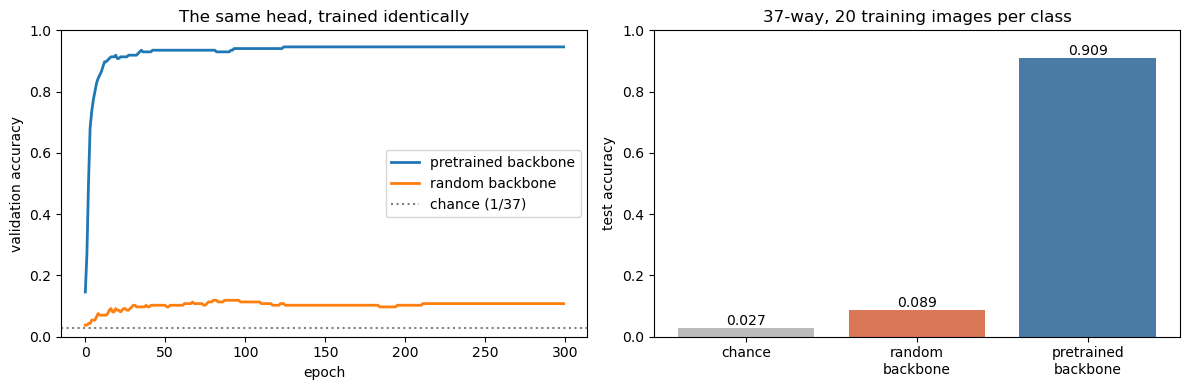

In [20]:
fig, (ax_curve, ax_bar) = plt.subplots(1, 2, figsize=(12, 4))

ax_curve.plot(probe_hist["val_acc"], label="pretrained backbone", lw=2)
ax_curve.plot(rand_hist["val_acc"], label="random backbone", lw=2)
ax_curve.axhline(chance, ls=":", c="grey", label="chance (1/37)")
ax_curve.set_xlabel("epoch"); ax_curve.set_ylabel("validation accuracy")
ax_curve.set_title("The same head, trained identically"); ax_curve.legend(); ax_curve.set_ylim(0, 1)

names = ["chance", "random\nbackbone", "pretrained\nbackbone"]
values = [chance, rand_test, probe_test]
bars = ax_bar.bar(names, values, color=["#bbb", "#d97757", "#4a7ba7"])
ax_bar.bar_label(bars, fmt="%.3f")
ax_bar.set_ylabel("test accuracy"); ax_bar.set_ylim(0, 1)
ax_bar.set_title(f"37-way, {TRAIN_PER_CLASS} training images per class")
plt.tight_layout()
plt.show()

### 9.1 What the two feature spaces look like

The accuracy gap says the pretrained features are better. It does not say what
"better" means. Since both backbones handed us a cached $740 \times 768$ matrix,
we can look.

Two caveats about the picture below. It shows the first two principal
components, so it is a 2-D shadow of a 768-dimensional space and can only
reveal the coarsest structure — here, cats against dogs. And PCA is unsupervised:
it never sees a label, it just finds the directions of greatest variance. That
the labels line up with those directions at all is the finding.

For a claim at *breed* level we need a measure that uses all 768 dimensions, so
alongside the plot we run a **1-nearest-neighbour** classifier: label each test
image by its closest training image in feature space. It trains nothing and
tunes nothing, so whatever accuracy it reaches is a property of the
representation alone.

In [21]:
# The 12 cat breeds in Oxford-IIIT Pet; the other 25 are dogs.
CAT_BREEDS = {
    "Abyssinian", "Bengal", "Birman", "Bombay", "British Shorthair",
    "Egyptian Mau", "Maine Coon", "Persian", "Ragdoll", "Russian Blue",
    "Siamese", "Sphynx",
}
unmatched = CAT_BREEDS - set(CLASSES)
assert not unmatched, f"breed names do not match this torchvision version: {unmatched}"

is_cat = torch.tensor([CLASSES[c] in CAT_BREEDS for c in range(N_CLASSES)])
print(f"{int(is_cat.sum())} cat breeds, {int((~is_cat).sum())} dog breeds")


def project_2d(X):
    """First two principal components, and the fraction of variance they carry."""
    centred = X - X.mean(0, keepdim=True)
    _, S, V = torch.pca_lowrank(centred, q=8)
    coords = centred @ V[:, :2]
    explained = (S[:2] ** 2).sum() / (centred ** 2).sum()
    return coords.numpy(), explained.item()


@torch.no_grad()
def nearest_neighbour_accuracy(X_train, y_train, X_test, y_test):
    """Label each test point by its closest training point. No training at all."""
    distances = torch.cdist(X_test, X_train)          # (n_test, n_train)
    nearest = distances.argmin(dim=1)
    return (y_train[nearest] == y_test).float().mean().item()

12 cat breeds, 25 dog breeds


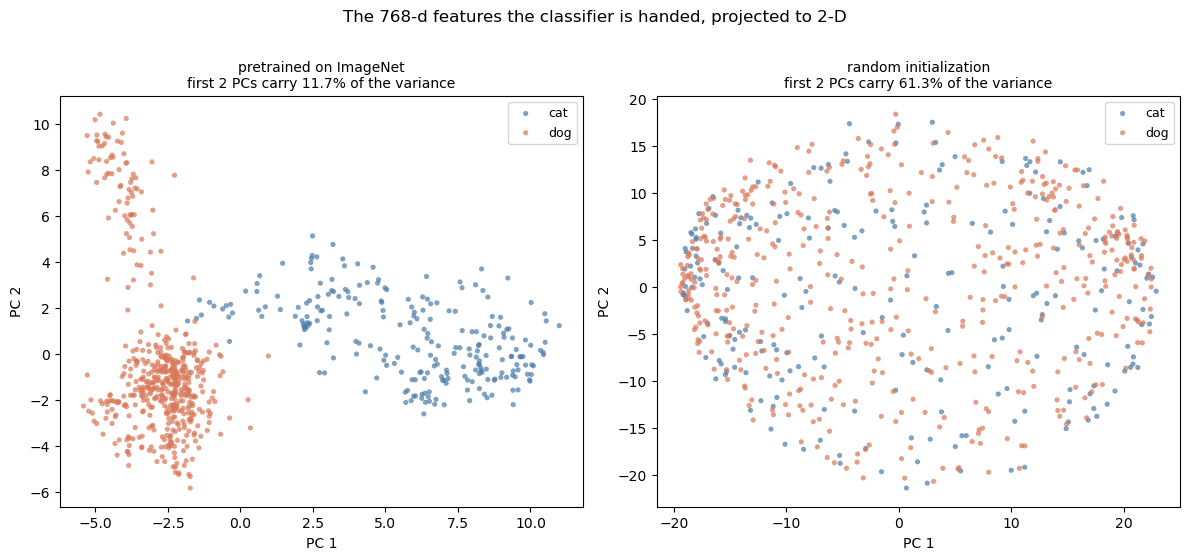

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=False)

for ax, X, name in [(axes[0], Xtr, "pretrained on ImageNet"),
                    (axes[1], Rtr, "random initialization")]:
    coords, explained = project_2d(X)
    species = is_cat[ytr].numpy()
    for mask, label, colour in [(species, "cat", "#4a7ba7"), (~species, "dog", "#d97757")]:
        ax.scatter(coords[mask, 0], coords[mask, 1], s=14, alpha=0.7,
                   c=colour, label=label, edgecolors="none")
    ax.set_title(f"{name}\nfirst 2 PCs carry {explained:.1%} of the variance", fontsize=10)
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2"); ax.legend(loc="best", fontsize=9)

fig.suptitle("The 768-d features the classifier is handed, projected to 2-D", y=1.01)
plt.tight_layout()
plt.show()

In [23]:
knn_pretrained = nearest_neighbour_accuracy(Xtr, ytr, Xte, yte)
knn_random = nearest_neighbour_accuracy(Rtr, ytr, Rte, yte)

print("1-nearest-neighbour in feature space — no training, no fitting:")
print(f"  pretrained backbone : {knn_pretrained:.4f}")
print(f"  random backbone     : {knn_random:.4f}")
print(f"  chance              : {chance:.4f}")
print()
print("The pretrained number is the useful one: with nothing learned on this task,")
print("a test image's nearest neighbour already tends to be its own breed. That is")
print("what the linear head is exploiting, and why so few parameters suffice.")

1-nearest-neighbour in feature space — no training, no fitting:
  pretrained backbone : 0.8638
  random backbone     : 0.0508
  chance              : 0.0270

The pretrained number is the useful one: with nothing learned on this task,
a test image's nearest neighbour already tends to be its own breed. That is
what the linear head is exploiting, and why so few parameters suffice.


### 9.2 How little data it needs

Both feature sets are cached, so re-training the head on a subset costs seconds.
That makes the most informative experiment in the notebook cheap: sweep the
training-set size and watch the two curves separate.

The shape matters more than any single point. The pretrained curve starts high
and flattens early — most of what it can do, it can do from a handful of
examples per class — while the random curve climbs slowly from chance. *That
gap is data efficiency*, and it is the practical reason to fine-tune rather than
train from scratch.

In [24]:
def subsample_per_class(X, y, n_per_class, seed=SEED):
    """Keep n_per_class examples of each class, chosen without replacement."""
    generator = torch.Generator().manual_seed(seed)
    keep = []
    for c in range(N_CLASSES):
        idx = (y == c).nonzero(as_tuple=True)[0]
        keep.append(idx[torch.randperm(len(idx), generator=generator)][:n_per_class])
    keep = torch.cat(keep)
    return X[keep], y[keep]


SWEEP = [n for n in (1, 2, 5, 10, 20) if n <= TRAIN_PER_CLASS]
curves = {"pretrained": [], "random": []}

for n in SWEEP:
    for name, Xfull, Xtest in [("pretrained", Xtr, Xte), ("random", Rtr, Rte)]:
        Xs, ys = subsample_per_class(Xfull, ytr, n)
        head, _, _ = train_head(Xs, ys, Xva if name == "pretrained" else Rva, yva)
        with torch.no_grad():
            acc = (head(Xtest.to(device)).argmax(1).cpu() == yte).float().mean().item()
        curves[name].append(acc)
    print(f"{n:2d} per class ({n * N_CLASSES:3d} images)   "
          f"pretrained {curves['pretrained'][-1]:.4f}   random {curves['random'][-1]:.4f}")

 1 per class ( 37 images)   pretrained 0.7503   random 0.0432


 2 per class ( 74 images)   pretrained 0.8076   random 0.0443


 5 per class (185 images)   pretrained 0.8562   random 0.0584


10 per class (370 images)   pretrained 0.8605   random 0.0627


20 per class (740 images)   pretrained 0.9092   random 0.0886


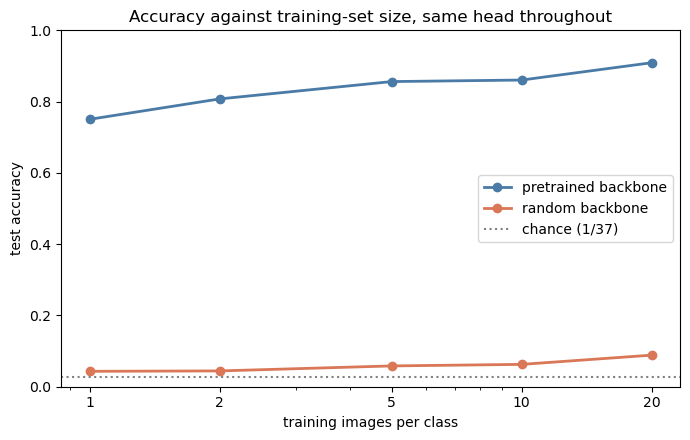

pretrained, 1 image per class:  0.7503
random, 20 images per class:    0.0886

One labelled example per breed, on top of a representation trained on
somebody else's data, beats twenty on top of a representation trained on none.


In [25]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(SWEEP, curves["pretrained"], "o-", lw=2, label="pretrained backbone", color="#4a7ba7")
ax.plot(SWEEP, curves["random"], "o-", lw=2, label="random backbone", color="#d97757")
ax.axhline(chance, ls=":", c="grey", label="chance (1/37)")
ax.set_xscale("log"); ax.set_xticks(SWEEP); ax.set_xticklabels(SWEEP)
ax.set_xlabel("training images per class"); ax.set_ylabel("test accuracy")
ax.set_ylim(0, 1); ax.legend()
ax.set_title("Accuracy against training-set size, same head throughout")
plt.tight_layout()
plt.show()

print(f"pretrained, {SWEEP[0]} image per class:  {curves['pretrained'][0]:.4f}")
print(f"random, {SWEEP[-1]} images per class:    {curves['random'][-1]:.4f}")
print("\nOne labelled example per breed, on top of a representation trained on")
print("somebody else's data, beats twenty on top of a representation trained on none.")

---
## 10. Strategy B: fine-tuning the attention layers

*This is the middle row of Section 6's table, and what the notes recommend.*

The linear probe never changes the representation — it only reads it. Fine-tuning
lets the representation move toward the new task, which is worth doing when the
target domain differs from ImageNet, and risky when data is scarce.

Four things change relative to Section 8, and each follows the notes:

- **The backbone is in the loop.** No cached features, so every epoch runs the full forward and backward pass. This is the expensive section.
- **Augmentation is back on**, since we are re-reading images anyway.
- **The learning rate is much lower** — $10^{-5}$ rather than $10^{-3}$. The pretrained weights are close to a good solution and large steps destroy them. This is the single most common way to ruin a fine-tune.
- **Warmup, then cosine decay.** Attention is unstable early; a few hundred warmup steps let the new random head settle before the backbone starts moving.

The head still gets the higher learning rate, because it *is* random and has
everything to learn. Two parameter groups, two rates.

In [26]:
class ViTClassifier(nn.Module):
    """Pretrained backbone plus a fresh head, trained end to end."""

    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.backbone = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
        self.backbone.heads = nn.Identity()
        self.head = nn.Linear(FEATURE_DIM, n_classes)

    def forward(self, x):
        return self.head(self.backbone(x))


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = count = 0
    for images, targets in loader:
        logits = model(images.to(device))
        correct += (logits.argmax(1).cpu() == targets).sum().item()
        count += targets.size(0)
    return correct / count

In [27]:
finetune_val = finetune_test = finetune_trainable = None

if RUN_FINETUNE:
    torch.manual_seed(SEED)
    model = ViTClassifier().to(device)

    # Freeze everything, then reopen only the attention layers (plus the head).
    for p in model.backbone.parameters():
        p.requires_grad = False
    for name, p in model.backbone.named_parameters():
        if "self_attention" in name:
            p.requires_grad = True

    backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
    finetune_trainable = (sum(p.numel() for p in backbone_params)
                          + sum(p.numel() for p in model.head.parameters()))
    print(f"trainable in backbone: {sum(p.numel() for p in backbone_params):,}")
    print(f"trainable in head:     {sum(p.numel() for p in model.head.parameters()):,}")

    optimizer = torch.optim.AdamW(
        [{"params": backbone_params, "lr": 1e-5},    # pretrained: nudge
         {"params": model.head.parameters(), "lr": 1e-3}],   # random: learn
        weight_decay=0.05,
    )
    steps = FINETUNE_EPOCHS * len(loaders["train_aug"])
    schedule = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=[1e-5, 1e-3], total_steps=steps, pct_start=0.25,
    )
    criterion = nn.CrossEntropyLoss()

    best_acc, best_state = 0.0, None
    for epoch in range(1, FINETUNE_EPOCHS + 1):
        model.train()
        t0 = time.time()
        for images, targets in loaders["train_aug"]:
            images, targets = images.to(device), targets.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), targets)
            loss.backward()
            optimizer.step()
            schedule.step()

        val_acc = evaluate(model, loaders["val"])
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        print(f"epoch {epoch}/{FINETUNE_EPOCHS}  val {val_acc:.4f}  ({time.time() - t0:.0f}s)")

    model.load_state_dict(best_state)
    finetune_val = best_acc
    finetune_test = evaluate(model, loaders["test"])
    print(f"\nfine-tuned test accuracy: {finetune_test:.4f}")
else:
    print("RUN_FINETUNE is False — skipping. Set it True on a machine with a GPU.")

trainable in backbone: 28,348,416
trainable in head:     28,453


epoch 1/4  val 0.8000  (28s)


epoch 2/4  val 0.9081  (27s)


epoch 3/4  val 0.9135  (26s)


epoch 4/4  val 0.9189  (26s)



fine-tuned test accuracy: 0.8930


---
## 11. Evaluation

*This is step 7 of the notes, including the refinement about looking past accuracy.*

With 37 classes, a single accuracy number hides almost everything. Two
diagnostics are worth the effort:

- the **confusion matrix**, which shows *which* breeds get mistaken for which — for a fine-grained task the errors are rarely uniform. We group its axes by species, so that if the model's mistakes respect the cat/dog boundary, the matrix says so as two blocks;
- **per-class precision, recall, and F1**, which reveal classes the model has effectively given up on. Accuracy can look respectable while a handful of classes sit near zero recall.

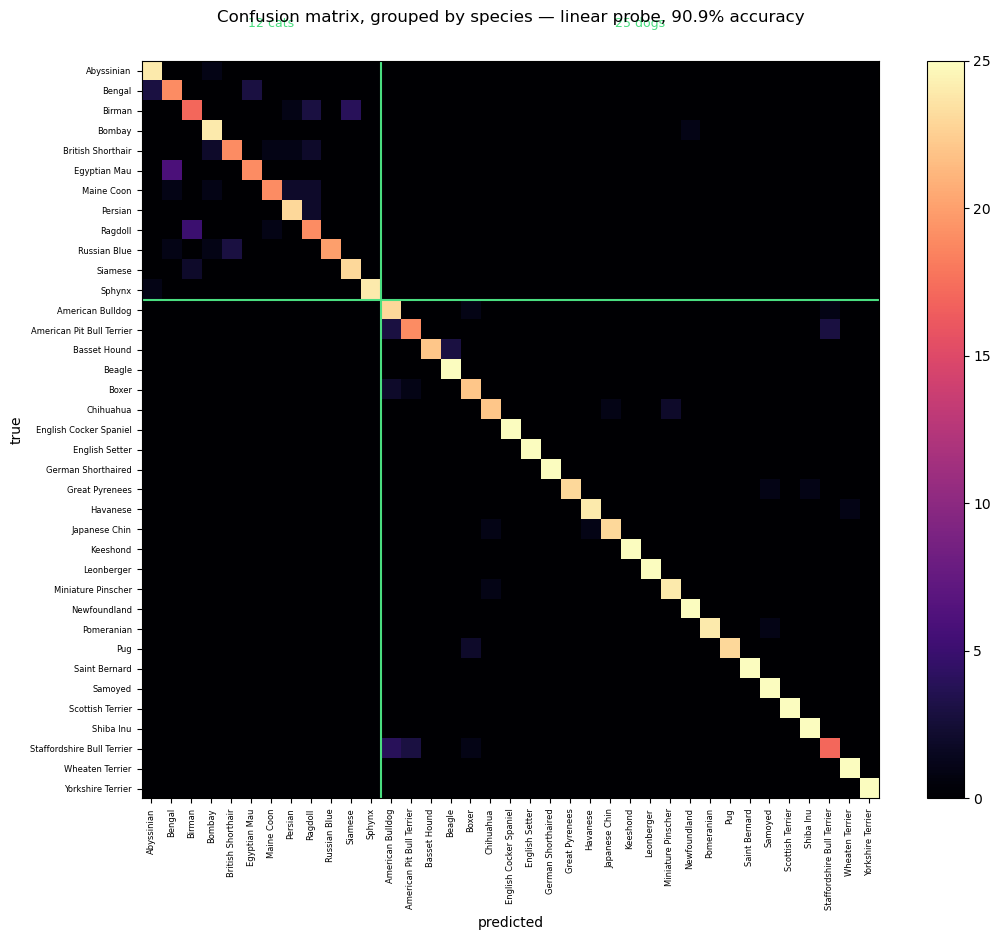

In [28]:
with torch.no_grad():
    predictions = probe_head(Xte.to(device)).argmax(1).cpu()

confusion = torch.zeros(N_CLASSES, N_CLASSES, dtype=torch.long)
for true, pred in zip(yte, predictions):
    confusion[true, pred] += 1

# Group the axes by species so any block structure becomes visible.
order = ([c for c in range(N_CLASSES) if is_cat[c]]
         + [c for c in range(N_CLASSES) if not is_cat[c]])
ordered = confusion[order][:, order]
names = [CLASSES[c] for c in order]
n_cats = int(is_cat.sum())

fig, ax = plt.subplots(figsize=(11, 9.5))
im = ax.imshow(ordered, cmap="magma")

ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(names, rotation=90, fontsize=6)
ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(names, fontsize=6)
ax.set_xlabel("predicted"); ax.set_ylabel("true")

# The line marking where cats end and dogs begin.
for draw in (ax.axhline, ax.axvline):
    draw(n_cats - 0.5, color="#4ade80", lw=1.5)
ax.text(n_cats / 2, -2.2, f"{n_cats} cats", ha="center", color="#4ade80", fontsize=9)
ax.text(n_cats + (N_CLASSES - n_cats) / 2, -2.2, f"{N_CLASSES - n_cats} dogs",
        ha="center", color="#4ade80", fontsize=9)

ax.set_title(f"Confusion matrix, grouped by species — linear probe, {probe_test:.1%} accuracy",
             pad=28)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

In [29]:
within_cat = ordered[:n_cats, :n_cats].sum().item()
within_dog = ordered[n_cats:, n_cats:].sum().item()
total = ordered.sum().item()
cross_species = total - within_cat - within_dog
errors = total - torch.diag(ordered).sum().item()

print(f"test images                      {total}")
print(f"  errors                         {errors}")
print(f"  of those, crossing cat <-> dog {cross_species}  "
      f"({100 * cross_species / max(errors, 1):.1f}% of errors)")
print()

off_diagonal = confusion - torch.diag(torch.diag(confusion))
worst = off_diagonal.flatten().topk(5)
print("most frequent confusions:")
for count, flat in zip(worst.values.tolist(), worst.indices.tolist()):
    t, p = divmod(flat, N_CLASSES)
    if count:
        same = "same species" if bool(is_cat[t]) == bool(is_cat[p]) else "ACROSS species"
        print(f"  {count:3d}x  {CLASSES[t]}  ->  {CLASSES[p]}   ({same})")

test images                      925
  errors                         84
  of those, crossing cat <-> dog 1  (1.2% of errors)

most frequent confusions:
    6x  Egyptian Mau  ->  Bengal   (same species)
    5x  Ragdoll  ->  Birman   (same species)
    4x  Staffordshire Bull Terrier  ->  American Bulldog   (same species)
    4x  Birman  ->  Siamese   (same species)
    3x  American Pit Bull Terrier  ->  American Bulldog   (same species)


In [30]:
# Precision, recall and F1 per class, straight from the confusion matrix.
tp = torch.diag(confusion).float()
precision = tp / confusion.sum(0).clamp(min=1)
recall = tp / confusion.sum(1).clamp(min=1)
f1 = 2 * precision * recall / (precision + recall).clamp(min=1e-9)

order = f1.argsort()
print(f"{'breed':28s} {'prec':>6s} {'rec':>6s} {'F1':>6s}")
print("  five weakest")
for i in order[:5].tolist():
    print(f"  {CLASSES[i]:26s} {precision[i]:6.2f} {recall[i]:6.2f} {f1[i]:6.2f}")
print("  five strongest")
for i in order[-5:].tolist():
    print(f"  {CLASSES[i]:26s} {precision[i]:6.2f} {recall[i]:6.2f} {f1[i]:6.2f}")

macro_f1 = f1.mean().item()
print(f"\nmacro F1: {macro_f1:.4f}   accuracy: {probe_test:.4f}")

if macro_f1 < probe_test - 0.01:
    print("Macro F1 sits below accuracy, so the weak classes are weaker than accuracy")
    print("suggests: macro F1 weights every breed equally, while accuracy is dominated")
    print("by whichever breeds happen to have the most test images.")
else:
    print("Macro F1 and accuracy agree, so performance is spread fairly evenly across")
    print("the 37 breeds rather than propped up by a few strong ones. On an imbalanced")
    print("dataset, or with a model that had given up on some classes, they would part.")

breed                          prec    rec     F1
  five weakest
  Birman                       0.71   0.68   0.69
  Ragdoll                      0.68   0.76   0.72
  Bengal                       0.70   0.76   0.73
  Staffordshire Bull Terrier   0.81   0.68   0.74
  American Pit Bull Terrier    0.83   0.76   0.79
  five strongest
  Leonberger                   1.00   1.00   1.00
  German Shorthaired           1.00   1.00   1.00
  English Setter               1.00   1.00   1.00
  English Cocker Spaniel       1.00   1.00   1.00
  Yorkshire Terrier            1.00   1.00   1.00

macro F1: 0.9090   accuracy: 0.9092
Macro F1 and accuracy agree, so performance is spread fairly evenly across
the 37 breeds rather than propped up by a few strong ones. On an imbalanced
dataset, or with a model that had given up on some classes, they would part.


---
## 12. Inference

*This is step 8 of the notes.*

The trained model on one image at a time. Note that inference uses the
**evaluation** transform — no augmentation — and that the softmax over logits
gives calibrated-looking scores that should be read with some caution.

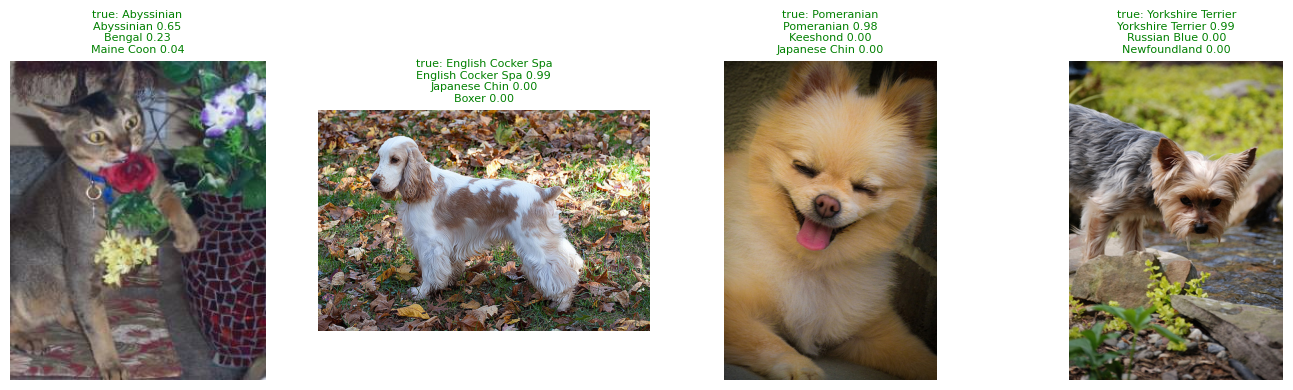

In [31]:
backbone.eval().to(device)


@torch.no_grad()
def classify(index, k=3):
    """Predict a single test image and return the top-k breeds."""
    image_raw, true_label = OxfordIIITPet(DATA_ROOT, split="test")[test_idx[index]]
    x = eval_transform(image_raw).unsqueeze(0).to(device)
    logits = probe_head(backbone(x))
    probs = logits.softmax(1)[0].cpu()
    top = probs.topk(k)
    return image_raw, true_label, [(CLASSES[i], p) for p, i in zip(top.values.tolist(), top.indices.tolist())]


fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, index in zip(axes, [0, len(test_idx) // 3, 2 * len(test_idx) // 3, len(test_idx) - 1]):
    image, true_label, top = classify(index)
    ax.imshow(image); ax.axis("off")
    correct = top[0][0] == CLASSES[true_label]
    lines = "\n".join(f"{name[:18]} {p:.2f}" for name, p in top)
    ax.set_title(f"true: {CLASSES[true_label][:18]}\n{lines}",
                 fontsize=8, color=("green" if correct else "red"))
plt.tight_layout()
plt.show()

---
## 13. What transferred, and what it cost

### The numbers

In [32]:
rows = [
    ("chance", 1 / N_CLASSES, 0, "—"),
    ("random backbone + linear head", rand_test, 28_453, f"{probe_time:.0f}s"),
    ("pretrained backbone + linear head", probe_test, 28_453, f"{probe_time:.0f}s"),
]
if finetune_test is not None:
    rows.append(("pretrained + attention fine-tuned", finetune_test, finetune_trainable, "minutes"))

print(f"{'':36s} {'test acc':>9s} {'trained':>12s} {'time':>9s}")
for name, acc, params, t in rows:
    print(f"{name:36s} {acc:9.4f} {params:12,} {t:>9s}")
print(f"\ntraining images: {len(train_idx)} ({TRAIN_PER_CLASS} per class, 37 classes)")

                                      test acc      trained      time
chance                                  0.0270            0         —
random backbone + linear head           0.0886       28,453        1s
pretrained backbone + linear head       0.9092       28,453        1s
pretrained + attention fine-tuned       0.8930   28,376,869   minutes

training images: 740 (20 per class, 37 classes)


### What the comparison shows

The pretrained and random backbones are the same architecture, fed the same
images, read by the same head, trained with the same optimizer for the same
number of epochs. The gap between them is the value of the ImageNet run,
measured rather than asserted.

It is worth being clear about *why* it is so large. With 20 images per class,
there is not enough evidence to learn what a useful image feature is. The
pretrained backbone does not need to: it already knows about edges, textures,
fur, ears, and the general structure of animals, because ImageNet contains a
great many animals. Our head has only to learn which combinations of those
features name which breed — a 37-way linear problem in 768 dimensions, which
740 examples are enough for.

This is the counterpart to notebook 4's lesson. There, the ViT's lack of
inductive bias cost it, because it had to learn from scratch what convolution
assumes for free. Here, the ViT starts with something better than an inductive
bias — an actual learned representation — and the same architecture that lost
to a 9,098-parameter CNN on MNIST wins comfortably.

**The lesson is not that transformers are better or worse. It is that where the
prior comes from matters more than the architecture.** A convolution's prior is
built in by its designer. A pretrained transformer's prior is learned from data
someone else paid for. Either beats learning from nothing.

### What fine-tuning did not buy

Section 10 trained a thousand times more parameters than the probe — 28.3M
attention weights against a 28K linear head — and finished *behind* it. That is
the notebook's second lesson, and it arrived by experiment rather than
assertion.

Two things are going on, and they are worth separating.

**Too many parameters for the data.** 28.3M trainable weights against 740
images is a severe ratio. The representation was already close to right, and
given that much freedom with that little evidence, a model can fit the training
set in ways that do not survive contact with the test set.

**Too few epochs to be sure.** Validation accuracy was still rising at the last
epoch, so this is not a converged comparison. The defensible claim is that
fine-tuning did not pay *at this budget, on this much data* — not that
fine-tuning is worse. Raise `FINETUNE_EPOCHS` and the ordering may well change.

The practical advice survives either reading: **start with the linear probe.**
It costs seconds rather than minutes, it sets a number that is hard to beat when
data is scarce, and it tells you whether the representation you are borrowing
suits your task at all — before you spend anything on adapting it.

### What this cost

A 330 MB checkpoint and a training run on 1.28 million labelled images that we
did not perform. Transfer learning is cheap for us precisely because it was
expensive for somebody else, and the checkpoint is the artifact that carries
that expense forward.

### What to try next

- **Extend the sweep in Section 9.2** past 20 images per class. The pretrained curve is still rising at the right-hand edge, and where the two curves would finally meet — if they ever do — is the number that says when pretraining stops mattering.
- **Give the fine-tune a longer budget.** `FINETUNE_EPOCHS = 4` left validation accuracy still climbing. Ten or twenty epochs would settle whether Section 10 lost because it overfits or because it never finished.
- **Compare the other freezing strategies** from Section 6 — the last two blocks, or everything — at a fixed budget. Section 10 measured one point on that axis; the shape of the whole curve is the interesting part.
- **Try a domain further from ImageNet** — medical images, satellite imagery, documents. The gap narrows as the target domain moves away from the pretraining distribution, and that is when full fine-tuning starts to pay.

### Refinements this notebook did not cover

The notes list several that matter in production and would have obscured the
comparison here: MixUp and CutMix augmentation, layer-wise learning-rate decay,
progressive unfreezing, and loss weighting for class imbalance. Oxford-IIIT Pet
is close to balanced, so the last one has nothing to act on — but on a skewed
dataset it is the first thing to reach for, and per-class recall in Section 11
is how you would notice you needed it.